###  MicroGrad demo

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from micrograd.engine import Value
from micrograd.nn import Neuron, Layer, MLP

In [3]:
np.random.seed(1337)
random.seed(1337)

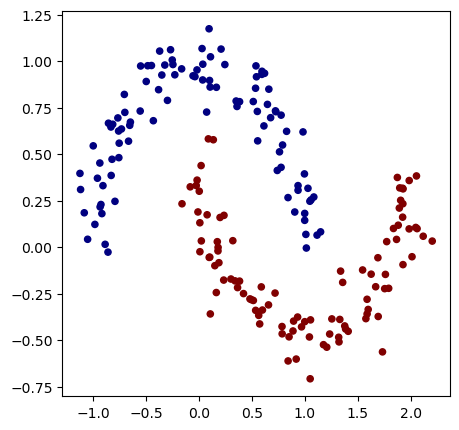

In [10]:
# make up a dataset

from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=200, noise=0.1)

y = y*2 - 1 # make y be -1 or 1
# visualize in 2D
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')

In [7]:
# initialize a model 
model = MLP(2, [16, 16, 1]) # 2-layer neural network
print(model)
print("number of parameters", len(model.parameters()))

MLP of [Layer of [ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2)], Layer of [ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16)], Layer of [LinearNeuron(16)]]
number of parameters 337


In [8]:
# loss function
def loss(batch_size=None):
    
    # inline DataLoader :)
    if batch_size is None:
        Xb, yb = X, y
    else:
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb = X[ri], y[ri]
    inputs = [list(map(Value, xrow)) for xrow in Xb]
    
    # forward the model to get scores
    scores = list(map(model, inputs))
    
    # svm "max-margin" loss
    losses = [(1 + -yi*scorei).relu() for yi, scorei in zip(yb, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))
    # L2 regularization
    alpha = 1e-4
    reg_loss = alpha * sum((p*p for p in model.parameters()))
    total_loss = data_loss + reg_loss
    
    # also get accuracy
    accuracy = [(yi > 0) == (scorei.data > 0) for yi, scorei in zip(yb, scores)]
    return total_loss, sum(accuracy) / len(accuracy)

total_loss, acc = loss()
print(total_loss, acc)

Value(data=0.9127024983383332, grad=0) 0.5


In [ ]:
# optimization
for k in range(100):
    
    # forward
    total_loss, acc = loss()
    
    # backward
    model.zero_grad()
    total_loss.backward()
    
    # update (sgd)
    learning_rate = 1.0 - 0.9*k/100
    for p in model.parameters():
        p.data -= learning_rate * p.grad
    
    if k % 1 == 0:
        print(f"step {k} loss {total_loss.data}, accuracy {acc*100}%")


step 0 loss 0.9127024983383332, accuracy 50.0%
step 1 loss 1.5749707835795705, accuracy 80.0%
step 2 loss 0.7788731630421228, accuracy 79.5%
step 3 loss 0.8158158104141815, accuracy 83.5%
step 4 loss 0.36967857707393686, accuracy 85.0%
step 5 loss 0.26985058122893607, accuracy 87.5%
step 6 loss 0.2481107008665279, accuracy 90.0%
step 7 loss 0.2234174566283698, accuracy 90.0%
step 8 loss 0.20463152330206127, accuracy 93.0%
step 9 loss 0.19632093391903604, accuracy 93.0%
step 10 loss 0.19733044506761419, accuracy 93.0%
step 11 loss 0.18470664659890298, accuracy 94.0%
step 12 loss 0.16970689418563503, accuracy 94.5%
step 13 loss 0.19099920473366427, accuracy 95.0%
step 14 loss 0.39252935946614653, accuracy 85.0%
step 15 loss 0.2967145959898762, accuracy 91.0%
step 16 loss 0.18146852441773367, accuracy 93.0%
step 17 loss 0.1350928786170388, accuracy 95.5%
step 18 loss 0.11901250062809099, accuracy 96.0%
step 19 loss 0.10844394155599493, accuracy 95.5%
step 20 loss 0.10637356930713819, accu

/home/fanscen/Lab/micrograd/micrograd/engine.py:26: RuntimeWarning: overflow encountered in scalar multiply
  out = Value(self.data * other.data, (self, other), '*')
/home/fanscen/Lab/micrograd/micrograd/engine.py:30: RuntimeWarning: overflow encountered in scalar multiply
  other.grad += self.data * out.grad
/home/fanscen/Lab/micrograd/micrograd/engine.py:30: RuntimeWarning: invalid value encountered in scalar multiply
  other.grad += self.data * out.grad


step 147 loss inf, accuracy 50.0%


/home/fanscen/Lab/micrograd/micrograd/engine.py:29: RuntimeWarning: overflow encountered in scalar multiply
  self.grad += other.data * out.grad
/home/fanscen/Lab/micrograd/micrograd/engine.py:29: RuntimeWarning: invalid value encountered in scalar add
  self.grad += other.data * out.grad
/home/fanscen/Lab/micrograd/micrograd/engine.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  self.grad += other.data * out.grad


step 148 loss inf, accuracy 50.0%
step 149 loss nan, accuracy 50.0%
step 150 loss nan, accuracy 50.0%
step 151 loss nan, accuracy 50.0%
step 152 loss nan, accuracy 50.0%
step 153 loss nan, accuracy 50.0%
step 154 loss nan, accuracy 50.0%
step 155 loss nan, accuracy 50.0%
step 156 loss nan, accuracy 50.0%
step 157 loss nan, accuracy 50.0%
step 158 loss nan, accuracy 50.0%
step 159 loss nan, accuracy 50.0%
step 160 loss nan, accuracy 50.0%
step 161 loss nan, accuracy 50.0%
step 162 loss nan, accuracy 50.0%
step 163 loss nan, accuracy 50.0%
step 164 loss nan, accuracy 50.0%
step 165 loss nan, accuracy 50.0%
step 166 loss nan, accuracy 50.0%
step 167 loss nan, accuracy 50.0%
step 168 loss nan, accuracy 50.0%
step 169 loss nan, accuracy 50.0%
step 170 loss nan, accuracy 50.0%
step 171 loss nan, accuracy 50.0%
step 172 loss nan, accuracy 50.0%
step 173 loss nan, accuracy 50.0%
step 174 loss nan, accuracy 50.0%
step 175 loss nan, accuracy 50.0%
step 176 loss nan, accuracy 50.0%
step 177 loss 

(-2.0610298589428298, 2.6889701410571702)

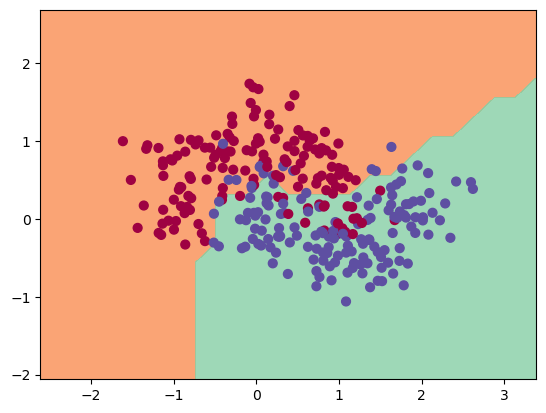

In [19]:
# visualize decision boundary

h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))
Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
